In [1]:
!pip cache purge

Files removed: 850 (228.8 MB)


# Data Import & Exploration

In [1]:
import pandas as pd
import numpy as np

# Load the dataset (Make sure the path matches where your file is saved)
# If your file is comma-separated, use sep=',' or remove the argument
df = pd.read_csv('fifa.csv', low_memory=False)

# 1. Check the dimensions of the dataset
print(f"Dataset Shape: {df.shape}")

# 2. Look at the column names and data types
print("\n--- Dataset Info ---")
print(df.info())

# 3. View the first 5 rows to spot obvious formatting issues
print("\n--- First 5 Rows ---")
df.head()

Dataset Shape: (18979, 77)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ID                18979 non-null  int64
 1   Name              18979 non-null  str  
 2   LongName          18979 non-null  str  
 3   photoUrl          18979 non-null  str  
 4   playerUrl         18979 non-null  str  
 5   Nationality       18979 non-null  str  
 6   Age               18979 non-null  int64
 7   ↓OVA              18979 non-null  int64
 8   POT               18979 non-null  int64
 9   Club              18979 non-null  str  
 10  Contract          18979 non-null  str  
 11  Positions         18979 non-null  str  
 12  Height            18979 non-null  str  
 13  Weight            18979 non-null  str  
 14  Preferred Foot    18979 non-null  str  
 15  BOV               18979 non-null  int64
 16  Best Position     18979 non-null  str 

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595


# Data Cleaning & Prep

In [3]:
# --- PRE-STEP 1: Fix & Expand Column Names --- 
rename_dict = {
    'POT': 'Potential', 
    'OVA': 'Overall', 
    '↓OVA': 'Overall',
    'BOV': 'Best_Overall',
    'A/W': 'Attack_Work_Rate',
    'D/W': 'Defensive_Work_Rate',
    'W/F': 'Weak_Foot',
    'SM': 'Skill_Moves',
    'IR': 'International_Reputation'
}
df = df.rename(columns=rename_dict)

# --- PRE-STEP 2: Drop Useless Columns (Case-Sensitive!) ---
columns_to_drop = ['playerUrl', 'photoUrl', 'Loan Date End']
df = df.drop(columns=columns_to_drop, errors='ignore')

# --- PRE-STEP 3: Global Whitespace Strip ---
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df[col] = df[col].astype(str).str.strip()


# --- PART A: Clean Financial Data ---
def clean_currency(x):
    if isinstance(x, str):
        x = x.replace('€', '').strip()
        if 'M' in x:
            x = float(x.replace('M', '')) * 1000000
        elif 'K' in x:
            x = float(x.replace('K', '')) * 1000
        else:
            x = float(x)
    return float(x)

financial_cols = ['Value', 'Wage', 'Release Clause']
for col in financial_cols:
    df[col] = df[col].fillna('0') 
    df[col] = df[col].apply(clean_currency)

# Create Moneyball Features
df['Wage_to_Value_Ratio'] = df['Wage'] / (df['Value'] + 1)
df['Potential_Growth'] = df['Potential'] - df['Overall']


# --- PART B: Clean Hits and Star Ratings ---
def clean_hits(x):
    if pd.isna(x):
        return 0
    if isinstance(x, str):
        x = x.replace(',', '')
        if 'K' in x:
            return float(x.replace('K', '')) * 1000
        else:
            return float(x)
    return float(x)

df['Hits'] = df['Hits'].apply(clean_hits)

star_columns = ['Weak_Foot', 'Skill_Moves', 'International_Reputation']
for col in star_columns:
    df[col] = df[col].astype(str).str.replace('★', '', regex=False).str.strip().astype(int)


# --- PART C: Clean Physical Traits & Contracts ---
def clean_height(x):
    if isinstance(x, str):
        if 'cm' in x:
            return int(x.replace('cm', ''))
        elif "'" in x:
            parts = x.split("'")
            feet = int(parts[0])
            inches = int(parts[1].replace('"', ''))
            return round((feet * 12 + inches) * 2.54)
    return x

df['Height'] = df['Height'].apply(clean_height)

def clean_weight(x):
    if isinstance(x, str):
        if 'kg' in x:
            return int(x.replace('kg', ''))
        elif 'lbs' in x:
            lbs = int(x.replace('lbs', ''))
            return round(lbs / 2.20462)
    return x

df['Weight'] = df['Weight'].apply(clean_weight)

def extract_contract_end(x):
    if isinstance(x, str):
        if '~' in x:
            return x.split('~')[1].strip()
        elif 'On Loan' in x:
            return x[-12:-8]
        elif 'Free' in x:
            return 'Free'
    return str(x)

df['Contract_Valid_Until'] = df['Contract'].apply(extract_contract_end)


# --- FINAL HOUSEKEEPING: Drop Redundant Columns ---
df = df.drop(columns=['LongName', 'Contract'], errors='ignore')

# --- FINAL CHECK ---
print("--- Master Cleaning Complete! ---")
print(f"Final Dataset Shape: {df.shape}")
print("\nSample of Newly Cleaned Columns:")
print(df[['Name', 'Skill_Moves', 'Height', 'Weight', 'Contract_Valid_Until']].head())

--- Master Cleaning Complete! ---
Final Dataset Shape: (18979, 75)

Sample of Newly Cleaned Columns:
                Name  Skill_Moves  Height  Weight Contract_Valid_Until
0           L. Messi            4     170      72                 2021
1  Cristiano Ronaldo            5     187      83                 2022
2           J. Oblak            1     188      87                 2023
3       K. De Bruyne            4     181      70                 2023
4          Neymar Jr            5     175      68                 2022


C:\Users\dell\AppData\Local\Temp\ipykernel_7408\2569263675.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns


# Exploratory Data Analysis (EDA)

## QUESTION 1: Which factors have the greatest impact on a player’s market value?

In [3]:
# 1. Isolate only the numeric columns so the math doesn't crash on text names
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Calculate how every numeric column correlates specifically with Market 'Value'
value_correlations = numeric_df.corr()['Value'].sort_values(ascending=False)

# 3. Print the top drivers of market value
print("--- TOP 10 STATS THAT INCREASE MARKET VALUE ---")
print(value_correlations.head(11)) # Using 11 because 'Value' correlating with itself (1.0) will be first

print("\n--- STATS THAT DECREASE MARKET VALUE ---")
print(value_correlations.tail(5))

--- TOP 10 STATS THAT INCREASE MARKET VALUE ---
Value                       1.000000
Release Clause              0.966440
Wage                        0.814870
Best_Overall                0.563253
Overall                     0.552893
International_Reputation    0.533569
Potential                   0.528200
Reactions                   0.489513
Base Stats                  0.462458
PAS                         0.394543
DRI                         0.393347
Name: Value, dtype: float64

--- STATS THAT DECREASE MARKET VALUE ---
Goalkeeping        -0.011616
GK Diving          -0.012163
GK Kicking         -0.012592
Potential_Growth   -0.110061
ID                 -0.131001
Name: Value, dtype: float64


## QUESTION 2 & 3: How do Age and Rating impact Market Value?

In [4]:
# 1. Group players by Age and calculate the average stats for each year
age_analysis = df.groupby('Age')[['Overall', 'Potential', 'Value', 'Wage']].mean()

# 2. Convert Value and Wage to clean Millions/Thousands for easier reading
age_analysis['Value (Millions €)'] = (age_analysis['Value'] / 1000000).round(2)
age_analysis['Wage (Thousands €)'] = (age_analysis['Wage'] / 1000).round(2)
age_analysis['Overall'] = age_analysis['Overall'].round(1)

# 3. Display the career arc from age 18 to 35
print("--- PLAYER LIFECYCLE (AVERAGE STATS BY AGE) ---")
print(age_analysis[['Overall', 'Value (Millions €)', 'Wage (Thousands €)']].loc[18:35])

--- PLAYER LIFECYCLE (AVERAGE STATS BY AGE) ---
     Overall  Value (Millions €)  Wage (Thousands €)
Age                                                 
18      57.4                0.73                1.33
19      58.4                1.08                2.63
20      61.5                1.88                4.54
21      62.5                2.49                4.81
22      64.4                2.92                7.25
23      65.3                3.37                8.40
24      67.1                3.63                9.23
25      67.3                3.78               10.66
26      67.8                3.74               11.89
27      68.3                3.79               12.17
28      68.9                3.83               14.38
29      68.8                3.63               13.64
30      68.8                3.16               12.10
31      69.1                2.97               12.39
32      69.5                2.94               12.50
33      69.8                2.71               14.8

## QUESTION 4: Which young players have the highest future potential?

In [5]:
# 1. Filter for young, high-growth, and affordable players
moneyball_targets = df[(df['Age'] <= 23) & 
                       (df['Potential_Growth'] >= 5) & 
                       (df['Value'] < 15000000)]

# 2. Sort by highest Potential, then lowest Wage to find the best ROI
best_targets = moneyball_targets.sort_values(by=['Potential', 'Wage'], ascending=[False, True])

# 3. Display the Top 10 Hidden Gems
print("--- TOP 10 HIDDEN GEMS (HIGH POTENTIAL, LOW COST) ---")
print(best_targets[['Name', 'Age', 'Overall', 'Potential', 'Potential_Growth', 'Value', 'Wage']].head(10))

--- TOP 10 HIDDEN GEMS (HIGH POTENTIAL, LOW COST) ---
               Name  Age  Overall  Potential  Potential_Growth       Value  \
2757      T. Almada   19       73         89                16   8000000.0   
1664        T. Kubo   19       75         89                14  13500000.0   
8116      R. Cherki   16       67         88                21   3200000.0   
6235  J. Bellingham   17       69         88                19   3500000.0   
6836       F. Wirtz   17       68         88                20   3300000.0   
2962        A. Urzi   20       73         88                15   7500000.0   
3791          Pedri   17       72         88                16   6000000.0   
4233        J. Doku   18       71         88                17   4800000.0   
1781        B. Saka   18       75         88                13  13000000.0   
1761     Riqui Puig   20       75         88                13  13500000.0   

         Wage  
2757   8000.0  
1664  59000.0  
8116   2000.0  
6235   3000.0  
6836   

## QUESTIONS 5 & 6: Identifying Undervalued Gems & Investment Value

In [6]:
# 1. Define what a "Bargain" is: 
# High skill (75+), Realistic cost (between 0.5M and 5M)
# This removes the "ghost" free agents with 0 value
bargains = df[(df['Overall'] >= 75) & 
              (df['Value'] > 500000) & 
              (df['Value'] < 5000000)]

# 2. Sort these bargains: Highest Overall first, then Cheapest price
undervalued = bargains.sort_values(by=['Overall', 'Value'], ascending=[False, True])

# 3. Identify Best Value by Position
# We calculate 'Skill_per_Euro' (Overall / Value)
df['Skill_per_Euro'] = df['Overall'] / (df['Value'] + 1)
pos_investment = df.groupby('Best_Overall')['Skill_per_Euro'].mean().sort_values(ascending=False)

# 4. Print the results
print("--- TOP 10 TRUE BARGAIN PLAYERS (75+ Overall, 0.5M - 5M Value) ---")
print(undervalued[['Name', 'Overall', 'Value', 'Wage']].head(10))

print("\n--- BEST INVESTMENT BY POSITION (Highest Skill per Euro) ---")
print(pos_investment.head(10).round(6))

--- TOP 10 TRUE BARGAIN PLAYERS (75+ Overall, 0.5M - 5M Value) ---
             Name  Overall      Value     Wage
208   S. Mandanda       83  4000000.0  28000.0
262     G. Buffon       82  3400000.0  41000.0
362  L. Fabiański       81  2900000.0  26000.0
366          Pepe       81  4600000.0  13000.0
501   I. Akinfeev       80  3600000.0  40000.0
477   B. Ivanović       80  3800000.0  61000.0
679     B. Foster       79  1900000.0  12000.0
683    Pepe Reina       79  1900000.0  30000.0
672     N. Guzmán       79  3000000.0  40000.0
682      G. Ochoa       79  3000000.0  34000.0

--- BEST INVESTMENT BY POSITION (Highest Skill per Euro) ---
Best_Overall
80    4.618502
77    2.604529
79    2.556763
76    2.087953
72    1.901180
69    1.416151
75    1.401906
70    1.281076
73    1.271566
81    1.208959
Name: Skill_per_Euro, dtype: float64


## QUESTIONS 7 & 8: Salary Analysis (Fixed Grouping

In [7]:
# 1. Group by 'Best Position' instead of 'Best_Overall'
pos_salary = df.groupby('Best Position')['Wage'].mean().sort_values(ascending=False)

# 2. Correlation between Wage and Overall Performance
wage_performance_corr = df['Wage'].corr(df['Overall'])

# 3. Print the results
print("--- AVERAGE WAGE BY POSITION ---")
print(pos_salary.head(10).round(2))

print(f"\n--- Correlation between Wage and Overall Performance: {wage_performance_corr:.2f} ---")

--- AVERAGE WAGE BY POSITION ---
Best Position
CF     24163.46
LW     16120.70
RW     15166.61
CM     13582.43
CDM     9682.98
ST      9431.68
CAM     9399.43
RB      9096.25
LM      8949.02
LWB     8805.17
Name: Wage, dtype: float64

--- Correlation between Wage and Overall Performance: 0.59 ---


## QUESTION 9: Which clubs have the highest average player ratings?

In [8]:
# 1. Filter for clubs with at least 15 players to ensure data quality
club_performance = df.groupby('Club').filter(lambda x: len(x) >= 15)

# 2. Calculate average 'Overall' rating per club
club_ranking = club_performance.groupby('Club')['Overall'].mean().sort_values(ascending=False)

# 3. Print the results
print("--- TOP 10 CLUBS BY AVERAGE SQUAD RATING ---")
print(club_ranking.head(10).round(2))

--- TOP 10 CLUBS BY AVERAGE SQUAD RATING ---
Club
FC Bayern München      81.48
Real Madrid            79.77
Inter                  79.35
Napoli                 78.69
Chelsea                78.18
Manchester United      78.09
Juventus               78.07
Paris Saint-Germain    77.97
Liverpool              77.39
Sevilla FC             77.29
Name: Overall, dtype: float64


## Question 10: Countries with the highest-rated players

In [9]:
# Filter for countries with at least 15 players
nat_performance = df.groupby('Nationality').filter(lambda x: len(x) >= 15)
nat_ranking = nat_performance.groupby('Nationality')['Overall'].mean().sort_values(ascending=False)

print("--- TOP 10 NATIONALITIES BY AVERAGE OVERALL RATING ---")
print(nat_ranking.head(10).round(2))

--- TOP 10 NATIONALITIES BY AVERAGE OVERALL RATING ---
Nationality
Egypt             71.40
Brazil            70.95
Algeria           70.62
Ukraine           70.51
Russia            70.35
Czech Republic    70.20
Iran              70.11
Morocco           69.91
Gabon             69.62
Portugal          69.55
Name: Overall, dtype: float64


## QUESTION 11: Overall trends in player distribution

In [10]:
# 1. Top 10 Nationalities by total player count (Volume)
nat_distribution = df['Nationality'].value_counts().head(10)

# 2. Distribution by 'Best Position' (Landscape)
pos_distribution = df['Best Position'].value_counts()

# 3. Print the results
print("--- TOP 10 NATIONALITIES BY TOTAL PLAYER COUNT (Volume) ---")
print(nat_distribution)

print("\n--- PLAYER DISTRIBUTION BY POSITION (Frequency) ---")
print(pos_distribution)

--- TOP 10 NATIONALITIES BY TOTAL PLAYER COUNT (Volume) ---
Nationality
England        1705
Germany        1195
Spain          1065
France         1003
Argentina       943
Brazil          887
Japan           485
Netherlands     438
Italy           387
Sweden          380
Name: count, dtype: int64

--- PLAYER DISTRIBUTION BY POSITION (Frequency) ---
Best Position
CB     3686
ST     2680
CAM    2299
GK     2075
RM     1611
CDM    1445
LB     1086
RB     1079
CM     1047
LM      871
RW      298
RWB     277
LWB     261
LW      186
CF       78
Name: count, dtype: int64


## QUESTION 12: Identifying Release Clause Inefficiencies

In [ ]:
# 1. Filter: Find players where Release Clause is > 0 and strictly less than Market Value
inefficient_assets = df[(df['Release Clause'] > 0) & (df['Release Clause'] < df['Value'])]

# 2. Add Quality Filter: Focus only on "Impact Players" (Overall >= 70)
quality_bargains = inefficient_assets[inefficient_assets['Overall'] >= 70]

# 3. Calculate the 'Discount' percentage
quality_bargains['Discount_Pct'] = ((quality_bargains['Value'] - 
                                     quality_bargains['Release Clause']) / 
                                    quality_bargains['Value']) * 100

# 4. Sort by the highest discount percentage
final_targets = quality_bargains.sort_values(by='Discount_Pct', ascending=False)

# 5. Display the top 10 "Impact" bargain opportunities
print("--- TOP 10 IMPACT PLAYERS WITH UNDERVALUED RELEASE CLAUSES (70+ Overall) ---")
print(final_targets[['Name', 'Overall', 'Value', 'Release Clause', 'Discount_Pct']].head(10))

## QUESTION 13: High-Potential Players with Expiring Contracts

In [11]:
# 1. Convert 'Contract_Valid_Until' to numeric for easier filtering
# Note: Ensure your data is clean; this assumes years are 4-digit strings
df['Contract_Year'] = df['Contract_Valid_Until'].str[-4:] 
df['Contract_Year'] = pd.to_numeric(df['Contract_Year'], errors='coerce')

# 2. Filter criteria:
# - Young players (Age <= 23)
# - High potential (Potential >= 80)
# - Contract expiring this year or next (e.g., 2026 or 2027)
expiring_soon = df[(df['Age'] <= 23) & 
                   (df['Potential'] >= 80) & 
                   (df['Contract_Year'].isin([2026, 2027]))]

# 3. Sort by Potential (highest first)
top_targets = expiring_soon.sort_values(by='Potential', ascending=False)

# 4. Display the results
print("--- TOP HIGH-POTENTIAL YOUNGSTERS WITH EXPIRING CONTRACTS ---")
print(top_targets[['Name', 'Age', 'Overall', 'Potential', 'Contract_Valid_Until']].head(10))

--- TOP HIGH-POTENTIAL YOUNGSTERS WITH EXPIRING CONTRACTS ---
             Name  Age  Overall  Potential Contract_Valid_Until
280    João Félix   20       81         93                 2026
521  P. Estupiñán   22       79         86                 2027


## QUESTION 14. Do players with 5-star Skill Moves or 5-star Weak Foot command a higher wage than players with the exact same Overall rating who lack those traits?

In [12]:
# 1. Create a boolean series to flag the 5-star players
df['Has_5Star_Skills'] = (df['Skill_Moves'] == 5)
df['Has_5Star_WeakFoot'] = (df['Weak_Foot'] == 5)

# 2. Now perform the groupby using these new boolean columns
skill_premium = df.groupby(['Overall', 'Has_5Star_Skills'])['Wage'].mean().unstack()
wf_premium = df.groupby(['Overall', 'Has_5Star_WeakFoot'])['Wage'].mean().unstack()

# 3. Print the comparison for high-rated players (Overall 80+)
print("--- WAGE COMPARISON: SKILL MOVES PREMIUM (Overall 80+) ---")
# Renaming columns for clarity (False = Normal, True = 5-Star)
print(skill_premium.loc[80:].rename(columns={False: 'Normal Skill', True: '5-Star Skill'}))

print("\n--- WAGE COMPARISON: WEAK FOOT PREMIUM (Overall 80+) ---")
print(wf_premium.loc[80:].rename(columns={False: 'Normal WF', True: '5-Star WF'}))

--- WAGE COMPARISON: SKILL MOVES PREMIUM (Overall 80+) ---
Has_5Star_Skills   Normal Skill   5-Star Skill
Overall                                       
80                 50701.526718   51500.000000
81                 54494.382022   53166.666667
82                 64067.796610   26000.000000
83                 77363.636364  133500.000000
84                 89976.190476  110000.000000
85                118593.750000  153000.000000
86                147153.846154  190000.000000
87                167352.941176  144000.000000
88                211000.000000            NaN
89                273333.333333            NaN
90                226000.000000  160000.000000
91                245000.000000  270000.000000
92                          NaN  220000.000000
93                560000.000000            NaN

--- WAGE COMPARISON: WEAK FOOT PREMIUM (Overall 80+) ---
Has_5Star_WeakFoot      Normal WF      5-Star WF
Overall                                         
80                   50663.200000

## QUESTION 15. How heavily do Height and Weight correlate with a player's Overall rating for specific positions?

In [13]:
# 1. Select relevant columns
physical_cols = ['Height', 'Weight', 'Overall', 'Best Position']

# 2. Group by Position and calculate correlation with 'Overall'
# We use a lambda to get correlation for each group
pos_physical_corr = df[physical_cols].groupby('Best Position').apply(
    lambda x: x[['Height', 'Weight']].corrwith(x['Overall'])
)

# 3. Print the results
print("--- PHYSICAL ATTRIBUTE CORRELATION WITH OVERALL BY POSITION ---")
print(pos_physical_corr.sort_values(by='Height', ascending=False))

--- PHYSICAL ATTRIBUTE CORRELATION WITH OVERALL BY POSITION ---
                 Height    Weight
Best Position                    
CF             0.299000  0.354802
GK             0.157773  0.284073
ST             0.152080  0.267480
CB             0.145668  0.291979
CM             0.098011  0.176470
CDM            0.083145  0.196199
CAM            0.041493  0.162519
RWB            0.036506  0.140499
LWB            0.027407  0.126651
RB             0.027355  0.175911
LM             0.014809  0.105121
RM             0.004704  0.155993
LB            -0.012468  0.139915
RW            -0.082719 -0.003450
LW            -0.105043  0.085707


## QUESTION 16. Are players who can play multiple positions cheaper or more expensive on average than single-position specialists?

In [14]:
# 1. Count how many positions each player can play
df['Num_Positions'] = df['Positions'].apply(lambda x: len(x.split(',')))

# 2. Calculate average Wage and Overall rating by versatility
versatility_analysis = df.groupby('Num_Positions')['Wage'].mean().sort_index()
versatility_rating = df.groupby('Num_Positions')['Overall'].mean().sort_index()

# 3. Print the formatted findings
print("--- VERSATILITY VALUE SUMMARY ---")
for pos_count in versatility_analysis.index:
    avg_overall = versatility_rating[pos_count]
    avg_wage = versatility_analysis[pos_count]
    
    # Format: X Position(s): Overall Y | Wage Z
    suffix = "Position" if pos_count == 1 else "Positions"
    print(f"{pos_count} {suffix}: Overall {avg_overall:.2f} | Wage {avg_wage:,.0f}")

--- VERSATILITY VALUE SUMMARY ---
1 Position: Overall 64.73 | Wage 8,137
2 Positions: Overall 66.45 | Wage 9,945
3 Positions: Overall 67.75 | Wage 10,660


## QUESTION 17. Does a high Hits count (popularity/hype) correlate with an inflated market value?

In [15]:
# =====================================================================
# QUESTION 17: Hype vs. Market Value (Hits Correlation)
# =====================================================================

# 1. Calculate the correlation coefficient between Hits and Value
hype_corr = df['Hits'].corr(df['Value'])

# 2. To visualize this, let's look at the average Value of "Trending" vs "Non-Trending" players
# We define "Trending" as players with Hits above the median
median_hits = df['Hits'].median()
df['Is_Trending'] = df['Hits'] > median_hits

trending_comparison = df.groupby('Is_Trending')['Value'].mean()

# 3. Print the findings
print(f"--- CORRELATION: HITS VS. MARKET VALUE: {hype_corr:.4f} ---")
print("\n--- AVERAGE VALUE: TRENDING (High Hits) VS. OBSCURE (Low Hits) ---")
print(trending_comparison.map('€{:,.0f}'.format))

--- CORRELATION: HITS VS. MARKET VALUE: 0.3762 ---

--- AVERAGE VALUE: TRENDING (High Hits) VS. OBSCURE (Low Hits) ---
Is_Trending
False      €736,861
True     €5,314,799
Name: Value, dtype: str


## QUESTION 18. At what exact age do players typically reach their peak Overall rating, and at what age does their Market Value begin to drastically decline?

In [16]:
# 1. Group by Age to see performance and financial trends
age_trends = df.groupby('Age')[['Overall', 'Value']].mean()

# 2. Find the age with the highest Overall rating
peak_performance_age = age_trends['Overall'].idxmax()

# 3. Find the age where Market Value begins its sharpest decline
# We look at the percentage change in value year-over-year
age_trends['Val_Change'] = age_trends['Value'].pct_change()
value_peak_age = age_trends['Value'].idxmax()

# 4. Print the findings
print(f"--- PEAK AGE PERFORMANCE SUMMARY ---")
print(f"Age of Peak Overall Rating: {peak_performance_age}")
print(f"Age of Peak Market Value: {value_peak_age}")
print("\n--- AGE TREND TABLE (Trends) ---")
print(age_trends.round(2))

--- PEAK AGE PERFORMANCE SUMMARY ---
Age of Peak Overall Rating: 42
Age of Peak Market Value: 28

--- AGE TREND TABLE (Trends) ---
     Overall       Value  Val_Change
Age                                 
16     54.83   499571.43         NaN
17     56.37   716764.71        0.43
18     57.35   727776.18        0.02
19     58.39  1077946.10        0.48
20     61.48  1881203.84        0.75
21     62.54  2486962.35        0.32
22     64.42  2924338.49        0.18
23     65.33  3372150.17        0.15
24     67.05  3625504.91        0.08
25     67.29  3776715.09        0.04
26     67.76  3740947.94       -0.01
27     68.34  3787671.06        0.01
28     68.90  3830963.81        0.01
29     68.76  3634153.11       -0.05
30     68.82  3161668.46       -0.13
31     69.08  2967031.25       -0.06
32     69.48  2939960.19       -0.01
33     69.81  2712346.72       -0.08
34     69.33  1541792.72       -0.43
35     69.08  1272795.45       -0.17
36     68.86   593043.48       -0.53
37     68.46   695

## QUESTION 19. Is there a financial premium for left-footed players compared to right-footed players with the exact same overall ratings?

In [17]:
# 1. Group by Preferred Foot and Overall, then calculate mean Wage
foot_premium = df.groupby(['Overall', 'Preferred Foot'])['Wage'].mean().unstack()

# 2. Focus on the "Elite" and "Impact" levels (Overall 75+) 
# to ensure we are comparing professional-grade talent
print("--- WAGE COMPARISON: LEFT VS. RIGHT FOOTED (Overall 75+) ---")
print(foot_premium.loc[75:].round(0))

--- WAGE COMPARISON: LEFT VS. RIGHT FOOTED (Overall 75+) ---
Preferred Foot      Left     Right
Overall                           
75               24915.0   23171.0
76               27888.0   28184.0
77               29908.0   31847.0
78               35596.0   37284.0
79               45027.0   40146.0
80               45871.0   52159.0
81               59867.0   51892.0
82               81111.0   55857.0
83               78227.0   83720.0
84               77692.0   95967.0
85              147143.0  117667.0
86              139000.0  152083.0
87              179286.0  155538.0
88              192500.0  215625.0
89              250000.0  278000.0
90              250000.0  208000.0
91                   NaN  251250.0
92                   NaN  220000.0
93              560000.0       NaN


## QUESTION 20. Which specific clubs are the most financially efficient (maintaining a high average Overall rating while keeping their total Wage bills low)?

In [18]:
# 1. Group by Club and get mean values
club_stats = df.groupby('Club').agg({'Overall': 'mean', 'Wage': 'mean'})

# 2. Calculate count of players per club to filter out small samples
club_counts = df.groupby('Club')['Name'].count()

# 3. Add the count to our club_stats dataframe
club_stats['Player_Count'] = club_counts

# 4. Filter for clubs with at least 15 players
efficient_clubs = club_stats[club_stats['Player_Count'] >= 15].copy()

# 5. Define Efficiency: High Overall / Low Wage
efficient_clubs['Efficiency_Score'] = efficient_clubs['Overall'] / efficient_clubs['Wage']

# 6. Sort and Display
# Filter out 'No Club' before sorting
efficient_clubs = efficient_clubs[efficient_clubs.index != 'No Club']
efficient_clubs = efficient_clubs.sort_values(by='Efficiency_Score', ascending=False)

print("--- TOP 10 MOST FINANCIALLY EFFICIENT CLUBS ---")
print(efficient_clubs[['Overall', 'Wage', 'Efficiency_Score']].head(10))

--- TOP 10 MOST FINANCIALLY EFFICIENT CLUBS ---
                                    Overall        Wage  Efficiency_Score
Club                                                                     
Jorge Wilstermann                 64.600000  506.666667          0.127500
Sport Huancayo                    63.448276  500.000000          0.126897
Delfín SC                         63.111111  500.000000          0.126222
LDU Quito                         66.178571  525.000000          0.126054
Club Guaraní                      64.200000  511.666667          0.125472
Cusco FC                          62.625000  500.000000          0.125250
Always Ready                      62.571429  500.000000          0.125143
Sol de América                    62.566667  500.000000          0.125133
Universidad Católica del Ecuador  62.517241  500.000000          0.125034
Melgar FBC                        62.466667  500.000000          0.124933


# ---DATA VISUALIZATION---

## 1. The "Age Cliff" (Financial & Performance)
### Goal
Visualize the peak performance vs. market value decline.
### Plot
A dual-axis line chart.
- **X-axis:** Age
- **Primary Y-axis:** Average Overall
- **Secondary Y-axis:** Average Market Value

In [4]:
import matplotlib.pyplot as plt

# 1. Prepare data: Group by Age
age_stats = df.groupby('Age').agg({'Overall': 'mean', 'Value': 'mean'})

# 2. Setup the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. Plot Overall Rating (Primary Y-axis)
color = 'tab:blue'
ax1.set_xlabel('Age')
ax1.set_ylabel('Avg Overall Rating', color=color, fontsize=12)
ax1.plot(age_stats.index, age_stats['Overall'], color=color, marker='o', linewidth=2, label='Overall Rating')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# 4. Create the second Y-axis for Market Value
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Avg Market Value (€)', color=color, fontsize=12)
ax2.plot(age_stats.index, age_stats['Value'], color=color, marker='s', linestyle='--', linewidth=2, label='Market Value')
ax2.tick_params(axis='y', labelcolor=color)

# 5. Final touches
plt.title('The Age Cliff: Overall Rating vs. Market Value Trajectory', fontsize=14)
fig.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

## 2. The "Hype Tax" (Hits vs. Value)
**Goal:** Prove that popularity inflates player market value.
**Plot:** Scatter plot with a regression trendline.
- **X-axis:** Hits
- **Y-axis:** Market Value

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the top 10 nationalities by count
top_10_nationalities = df['Nationality'].value_counts().nlargest(10).index

# 2. Filter the dataframe for these top 10
df_top_10 = df[df['Nationality'].isin(top_10_nationalities)]

# 3. Create the Box Plot
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_10, x='Nationality', y='Wage', palette='viridis')

# 4. Final touches
plt.title('Wage Distribution by Top 10 Nationalities', fontsize=16)
plt.xlabel('Nationality', fontsize=12)
plt.ylabel('Wage (€)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

ModuleNotFoundError: No module named 'seaborn'

## 3. The "Versatility Premium"
**Goal:** Show how player versatility (playing multiple positions) affects average wage.
**Plot:** Grouped bar chart.
- **X-axis:** Number of Positions (1, 2, 3+)
- **Y-axis:** Average Wage

C:\Users\dell\AppData\Local\Temp\ipykernel_16364\1953090774.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=versatility_data, x='Num_Positions', y='Wage', palette='magma')


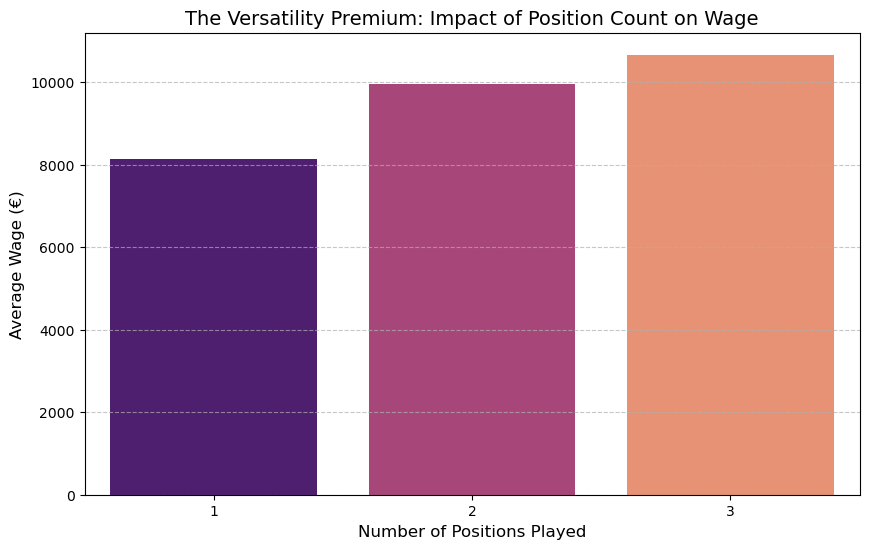

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure Num_Positions is calculated (if not already done)
# df['Num_Positions'] = df['Positions'].apply(lambda x: len(x.split(',')))

# 2. Group data for the chart
versatility_data = df.groupby('Num_Positions')['Wage'].mean().reset_index()

# 3. Create the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=versatility_data, x='Num_Positions', y='Wage', palette='magma')

# 4. Final touches
plt.title('The Versatility Premium: Impact of Position Count on Wage', fontsize=14)
plt.xlabel('Number of Positions Played', fontsize=12)
plt.ylabel('Average Wage (€)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 4. Financial Efficiency Leaders
**Goal:** Identify the smartest clubs by comparing their financial efficiency.
**Plot:** Horizontal bar chart of the Top 10 most efficient clubs.
- **X-axis:** Efficiency Score
- **Y-axis:** Club Name

C:\Users\dell\AppData\Local\Temp\ipykernel_16364\617628406.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_efficient, x='Efficiency_Score', y=top_10_efficient.index, palette='rocket')


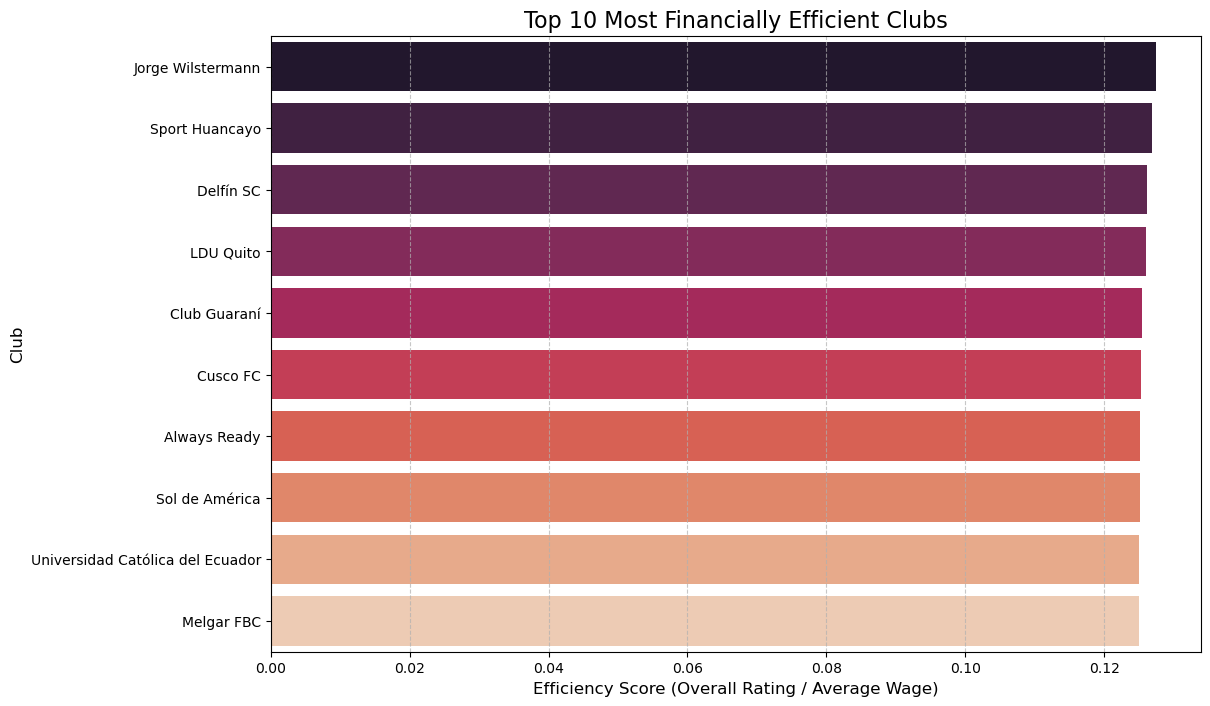

In [22]:
# 1. Ensure the calculation happens first
# Make sure this runs before sorting
club_stats['Efficiency_Score'] = club_stats['Overall'] / club_stats['Wage']

# 2. Now filter out 'No Club'
club_stats = club_stats[club_stats.index != 'No Club']

# 3. Now sort by the score
club_stats = club_stats.sort_values(by='Efficiency_Score', ascending=False)

# 4. Select top 10
top_10_efficient = club_stats.head(10)

# 5. Create the Horizontal Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_efficient, x='Efficiency_Score', y=top_10_efficient.index, palette='rocket')

plt.title('Top 10 Most Financially Efficient Clubs', fontsize=16)
plt.xlabel('Efficiency Score (Overall Rating / Average Wage)', fontsize=12)
plt.ylabel('Club', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 5. Physicality vs. Overall (The "Myth-Buster")
**Goal:** Investigate whether greater height or weight leads to a higher overall rating.
**Plot:** Heatmap or a grid of scatter plots for different positions (CF, CB, CAM).
- **X-axis:** Height / Weight
- **Y-axis:** Overall Rating

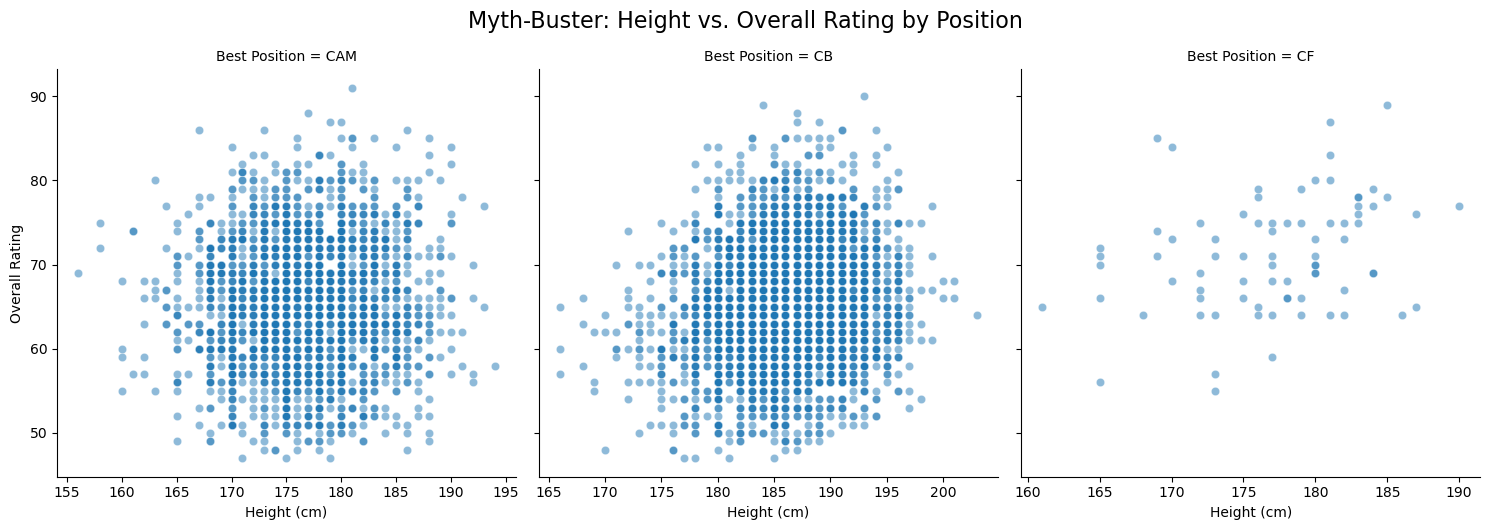

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for specific positions to keep the chart clean
# Focusing on positions where physical presence is often debated
positions_to_plot = ['CF', 'CB', 'CAM']
df_phys = df[df['Best Position'].isin(positions_to_plot)]

# 2. Use FacetGrid to create a grid of plots
g = sns.FacetGrid(df_phys, col="Best Position", height=5, sharex=False, sharey=True)

# 3. Map the scatter plot to the grid
# Using Height on X-axis (ensure your dataset has a 'Height' column)
g.map(sns.scatterplot, "Height", "Overall", alpha=0.5)

# 4. Final touches
g.set_axis_labels("Height (cm)", "Overall Rating")
g.fig.suptitle('Myth-Buster: Height vs. Overall Rating by Position', y=1.05, fontsize=16)
plt.show()

## 6. The Correlation Heatmap (Feature Relationship)
**Goal:** Visualize the relationships and correlations among all numerical features in the dataset.

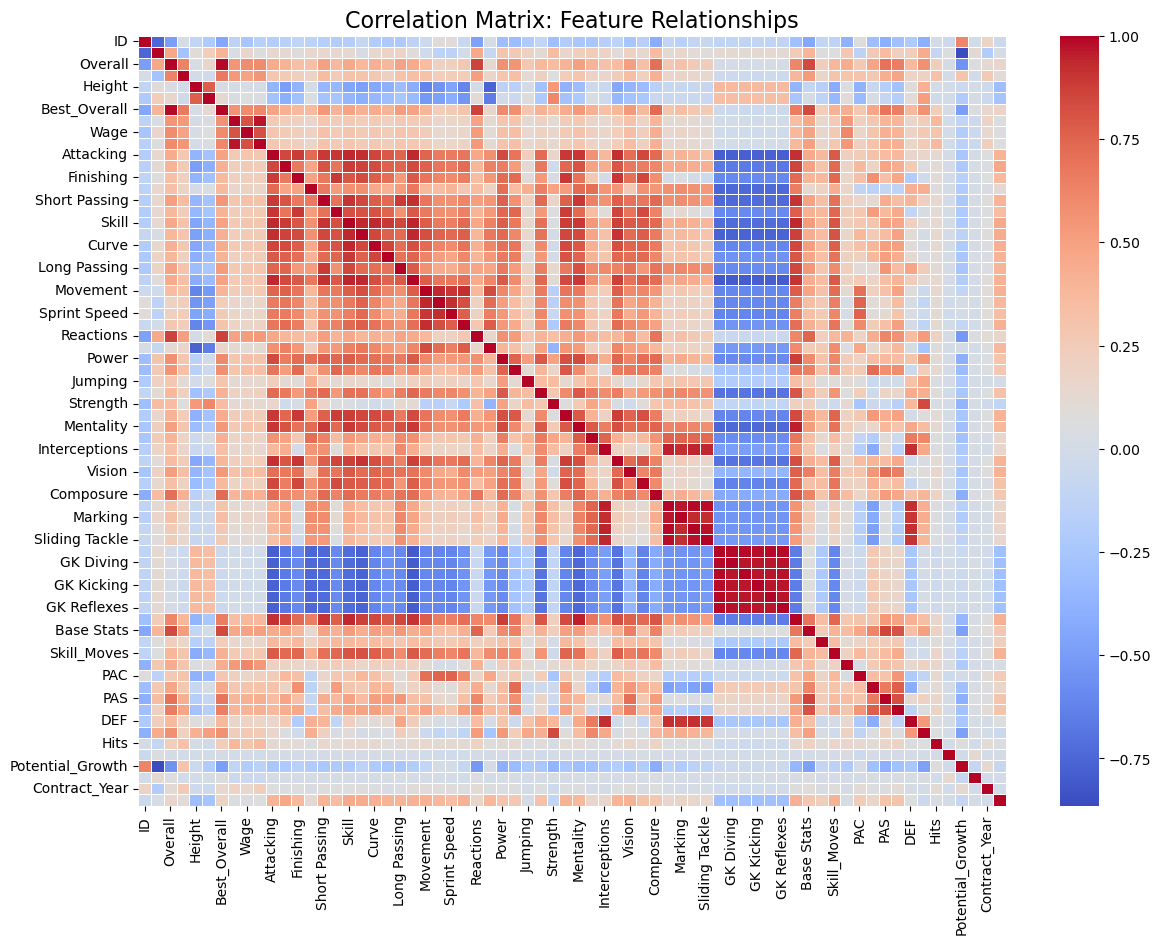

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Compute the correlation matrix
corr_matrix = numerical_df.corr()

# 3. Create the Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

# 4. Final touches
plt.title('Correlation Matrix: Feature Relationships', fontsize=16)
plt.show()

## 7. Top 10 Most Valuable Players

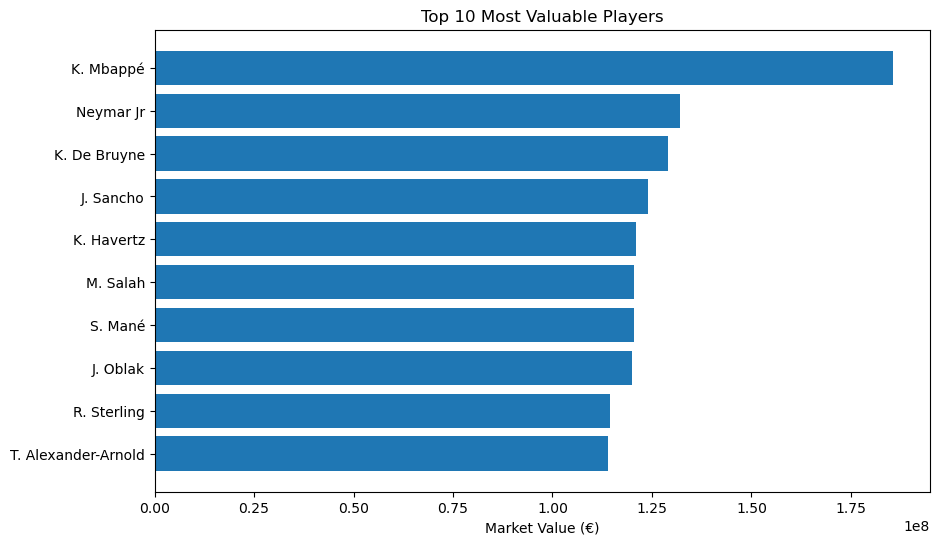

In [25]:
top10 = df.nlargest(10,'Value')

plt.figure(figsize=(10,6))

plt.barh(top10['Name'], top10['Value'])

plt.title("Top 10 Most Valuable Players")

plt.xlabel("Market Value (€)")

plt.gca().invert_yaxis()

plt.show()

 ## 8. Average Wage by Position

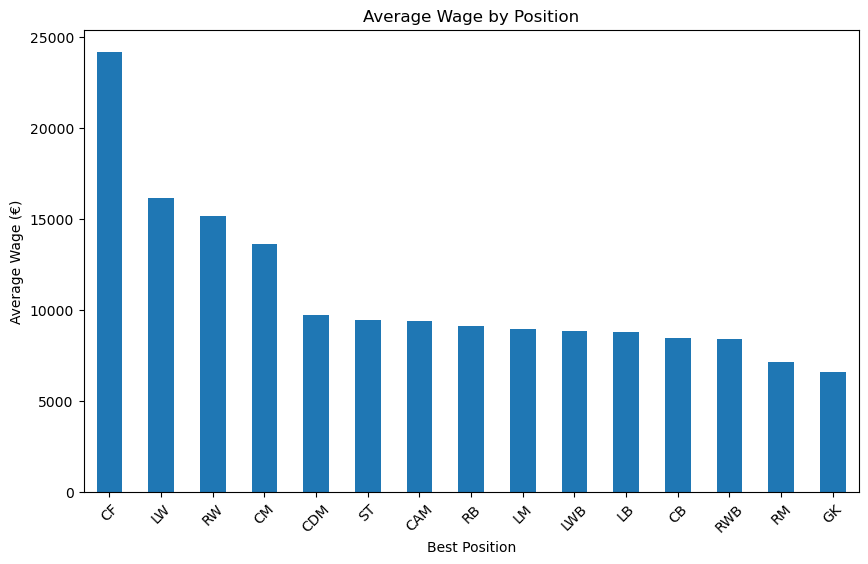

In [26]:
avg_wage = df.groupby('Best Position')['Wage'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

avg_wage.plot(kind='bar')

plt.title("Average Wage by Position")

plt.ylabel("Average Wage (€)")

plt.xticks(rotation=45)

plt.show()

## 9. Nationality Performance Map (Geographic Density)
**Goal:** Identify which countries produce the highest number of players and compare their average overall ratings to highlight global football talent hubs.
**Plot:** World map (using Plotly) or a horizontal bar chart of the Top 15 nationalities.
- **X-axis:** Nationality (Top 15 by player count)
- **Y-axis:** Mean Overall Rating

C:\Users\dell\AppData\Local\Temp\ipykernel_16364\3513332311.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_15_nations.index, rotation=45)


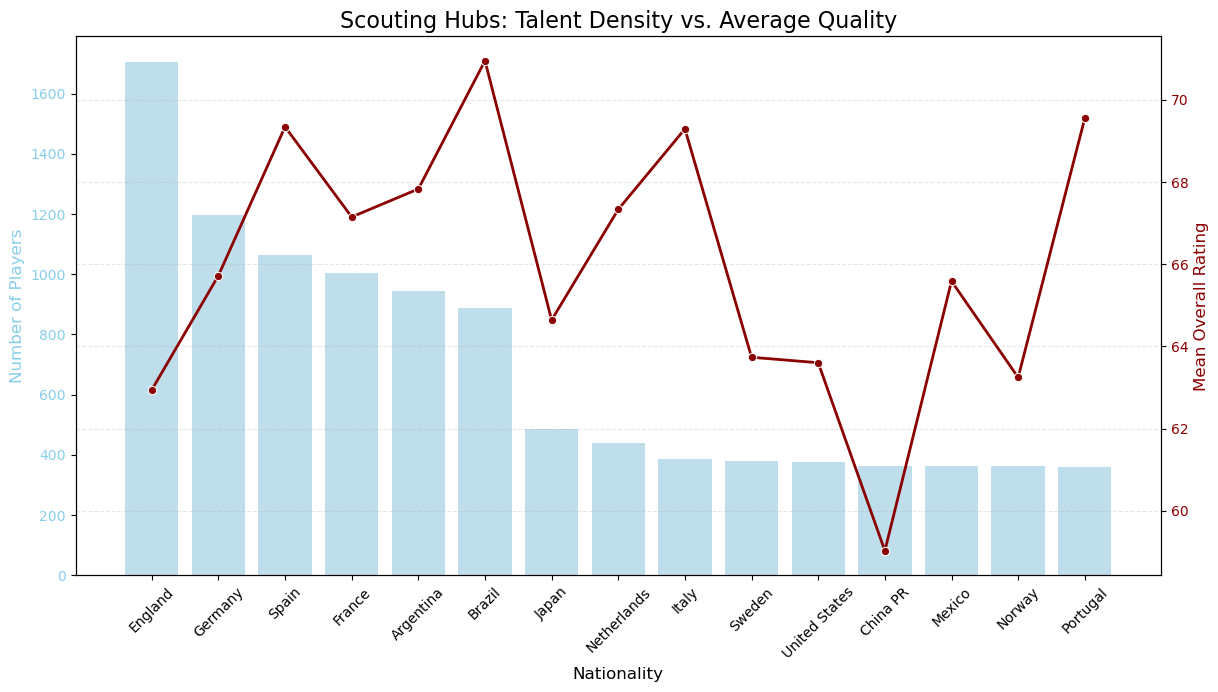

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Average Overall and Count per Nationality
nationality_stats = df.groupby('Nationality').agg({'Overall': 'mean', 'Name': 'count'})
nationality_stats = nationality_stats.rename(columns={'Name': 'Player_Count'})

# 2. Filter for Top 15 Nationalities by player count
top_15_nations = nationality_stats.nlargest(15, 'Player_Count')

# 3. Create a dual-axis plot: Bar for count, Line for mean rating
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart for Player Count
color1 = 'skyblue'
sns.barplot(x=top_15_nations.index, y=top_15_nations['Player_Count'], ax=ax1, color=color1, alpha=0.6)
ax1.set_ylabel('Number of Players', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlabel('Nationality', fontsize=12)
ax1.set_xticklabels(top_15_nations.index, rotation=45)

# Line chart for Mean Overall Rating
ax2 = ax1.twinx()
color2 = 'darkred'
sns.lineplot(x=top_15_nations.index, y=top_15_nations['Overall'], ax=ax2, color=color2, marker='o', linewidth=2)
ax2.set_ylabel('Mean Overall Rating', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Scouting Hubs: Talent Density vs. Average Quality', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 10. The "Age Distribution" Histogram
**Goal:** Visualize the age distribution of players to understand the overall workforce composition in the dataset.
**Plot:** Histogram (or distribution plot) of the `Age` column.
- **X-axis:** Age
- **Y-axis:** Number of Players (Frequency)

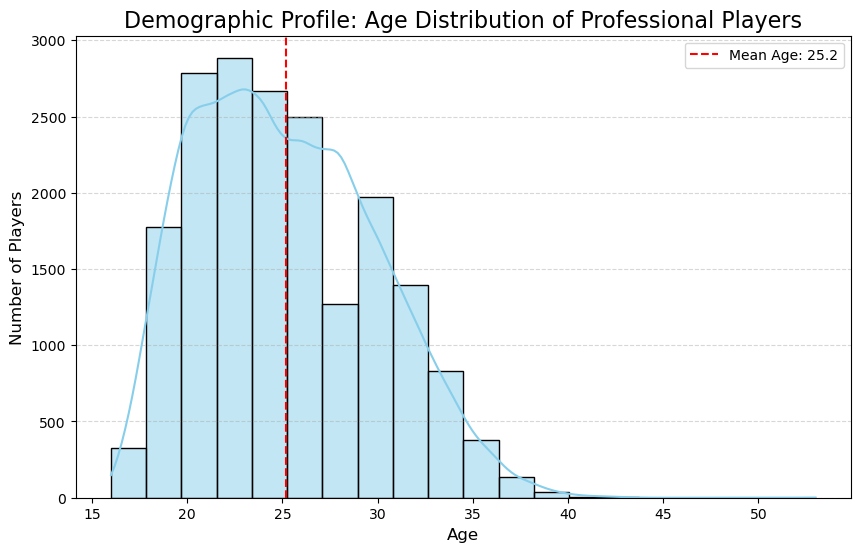

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the Histogram with a Kernel Density Estimate (KDE) line
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=20)

# 2. Add visual markers for context
mean_age = df['Age'].mean()
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean Age: {mean_age:.1f}')

# 3. Final touches
plt.title('Demographic Profile: Age Distribution of Professional Players', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Export your cleaned dataframe to a CSV file

In [30]:
df.to_csv('cleaned_fifa21_data.csv', index=False)